In [1]:
import os

ucl_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL"

for root, dirs, files in os.walk(ucl_path):
    level = root.replace(ucl_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for f in sorted(files)[:10]:  # first 10 files per folder
        size_kb = os.path.getsize(os.path.join(root, f)) // 1024
        print(f"{sub_indent}📄 {f}  ({size_kb} KB)")
    if len(files) > 10:
        print(f"{sub_indent}... and {len(files)-10} more files")

📁 UCL/
  📁 Database/
    📄 (1) Infant Demographics.xlsx  (68 KB)
    📄 (2) Study details.xlsx  (31 KB)
    📄 (3) Stimulation information.xlsx  (65 KB)
    📄 (4) Infant patient notes.xlsx  (189 KB)
    📄 (5) Maternal patient notes.xlsx  (18 KB)
    📄 ~$(3) Stimulation information.xlsx  (0 KB)
  📁 EEG/
    📁 2510001/
      📄 2510001A01.mat  (596 KB)
      📄 2510001C01.mat  (596 KB)
      📄 2510001L01.mat  (7374 KB)
    📁 2510101/
      📄 2510101A01.mat  (625 KB)
      📄 2510101C01.mat  (625 KB)
      📄 2510101L01.mat  (7818 KB)
    📁 2510201/
      📄 2510201A01.mat  (605 KB)
      📄 2510201C01.mat  (609 KB)
      📄 2510201L01.mat  (7765 KB)
    📁 2510301/
      📄 2510301A01.mat  (625 KB)
      📄 2510301C01.mat  (626 KB)
      📄 2510301L01.mat  (7202 KB)
    📁 2510401/
      📄 2510401A01.mat  (627 KB)
      📄 2510401C01.mat  (631 KB)
      📄 2510401L01.mat  (7717 KB)
    📁 2510501/
      📄 2510501A01.mat  (546 KB)
      📄 2510501C01.mat  (550 KB)
      📄 2510501L01.mat  (6750 KB)
    📁 25

In [2]:
import scipy.io
import numpy as np
import pandas as pd
import os

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
db_path      = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"

# ── STEP 1: Correctly load one .mat file ─────────────────────────────
mat = scipy.io.loadmat(
    f"{ucl_eeg_path}\\2510001\\2510001L01.mat",
    squeeze_me=True,
    struct_as_record=False
)
eeg = mat['EEG']

print("=" * 50)
print("SINGLE .MAT FILE INSPECTION")
print("=" * 50)
print(f"Subject       : {eeg.subject}")
print(f"Condition     : {eeg.condition}")
print(f"Sampling rate : {eeg.srate} Hz")
print(f"Channels      : {eeg.nbchan}")
print(f"Time points   : {eeg.pnts}")
print(f"Duration      : {eeg.pnts / eeg.srate:.1f} seconds")
print(f"EEG data shape: {eeg.data.shape}")
print(f"Time axis     : {eeg.times[0]:.3f}s to {eeg.times[-1]:.3f}s")

# Channel names
try:
    ch_names = [str(eeg.chanlocs[i].labels) for i in range(len(eeg.chanlocs))]
    print(f"Channel names : {ch_names}")
except Exception as ex:
    print(f"Channel names : could not parse — {ex}")

# other_data — HR and SpO2 pre-computed values
print(f"\nother_data type  : {type(eeg.other_data)}")
try:
    od = eeg.other_data
    if hasattr(od, 'dtype') and od.dtype.names:
        print(f"other_data fields: {od.dtype.names}")
        for name in od.dtype.names:
            print(f"  {name}: {od[name]}")
    else:
        print(f"other_data shape : {od.shape}")
        print(f"other_data value : {od}")
except Exception as ex:
    print(f"other_data error : {ex}")


SINGLE .MAT FILE INSPECTION
Subject       : 25100
Condition     : lance
Sampling rate : 2000 Hz
Channels      : 18
Time points   : 8000
Duration      : 4.0 seconds
EEG data shape: (18, 8000)
Time axis     : -2000.000s to 1999.500s
Channel names : ['Cz', 'CPz', 'F8', 'T8', 'TP10', 'P8', 'O2', 'F4', 'C4', 'CP4', 'F7', 'T7', 'TP9', 'P7', 'O1', 'F3', 'C3', 'CP3']

other_data type  : <class 'scipy.io.matlab._mio5_params.mat_struct'>
other_data error : 'mat_struct' object has no attribute 'shape'


In [3]:
import pandas as pd

db_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"

# File 1 — all sheets
xl1 = pd.ExcelFile(f"{db_path}\\(1) Infant Demographics.xlsx")
print("File 1 sheets:", xl1.sheet_names)

# File 2 — all sheets
xl2 = pd.ExcelFile(f"{db_path}\\(2) Study details.xlsx")
print("File 2 sheets:", xl2.sheet_names)

# File 3 — all sheets (3 tabs)
xl3 = pd.ExcelFile(f"{db_path}\\(3) Stimulation information.xlsx")
print("File 3 sheets:", xl3.sheet_names)

# File 4 — all sheets
xl4 = pd.ExcelFile(f"{db_path}\\(4) Infant patient notes.xlsx")
print("File 4 sheets:", xl4.sheet_names)

# File 5 — all sheets
xl5 = pd.ExcelFile(f"{db_path}\\(5) Maternal patient notes.xlsx")
print("File 5 sheets:", xl5.sheet_names)

File 1 sheets: ['Demographics', 'Delivery details', 'SNAP scores']
File 2 sheets: ['Study context', 'EEG details']
File 3 sheets: ['Heel lance', 'Sham control', 'Auditory control']
File 4 sheets: ['Ventilation', 'Diagnosis', 'Cranial scans', 'Medication', 'Heel lances', 'Painful procedures', 'Injuries']
File 5 sheets: ['Maternal']


## Next_Cell -- loads all 3 condition sheets from the stimulation Excel, stacks them into one big table, adds pain labels, adds gestational age from demographics, flags infants on analgesics from the medication sheet, builds the file path for each recording, checks which files actually exist on disk, and saves everything as ucl_master_labels.csv.

MASTER LABEL TABLE SUMMARY
Total records      : 310
Files found        : 308
Files missing      : 2

Condition counts:
condition
lance       112
sham         99
auditory     99

PIPP pain/no-pain (where available):
pipp_label
0.0    169
NaN     95
1.0     46

Age groups:
age_group
G3_oldest      199
G1_youngest     78
G2_middle       33

On analgesics: 3 infants

Sample lance rows with PIPP:
    Record identifier EEG file name condition  pain_label  Total PIPP score  pipp_label  Gestational age at birth (weeks)  age_group  on_analgesic  Baseline heart rate (bmp)  Max heart rate (bpm)  Baseline O2 sats  Min O2 sats  file_exists
10             254101     254101L01     lance           1              11.0         1.0                         35.714286  G3_oldest             0                      135.0                 159.0              97.0         96.0         True
11             254401     254401L01     lance           1              17.0         1.0                         37.000000  G3

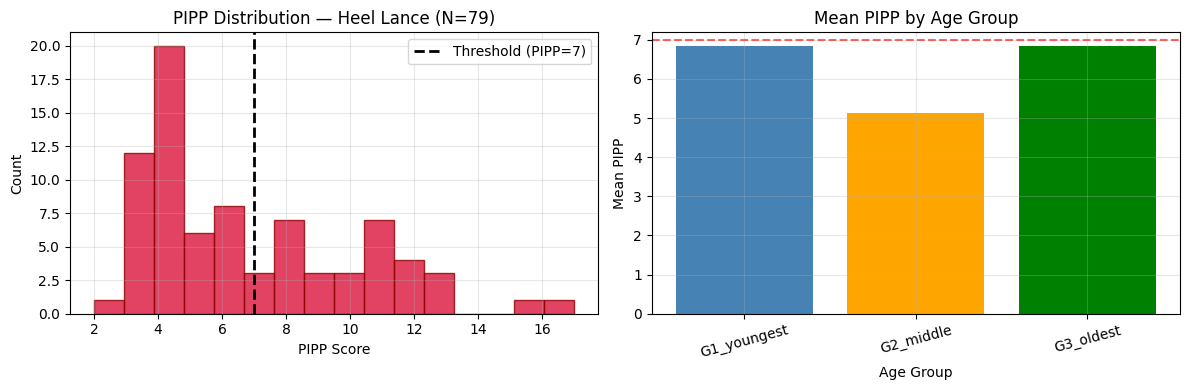


✅ Saved ucl_master_labels.csv — 310 rows


In [4]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
db_path      = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\Database"
save_path    = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"

# Load all 3 condition sheets from stimulation Excel
# header=1 because row 0 is a merged title, row 1 has real column names
lance_df    = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Heel lance',       header=1)
sham_df     = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Sham control',     header=1)
auditory_df = pd.read_excel(f"{db_path}\\(3) Stimulation information.xlsx",
                             sheet_name='Auditory control', header=1)

# Label each condition
lance_df['condition']    = 'lance';    lance_df['pain_label']    = 1
sham_df['condition']     = 'sham';     sham_df['pain_label']     = 0
auditory_df['condition'] = 'auditory'; auditory_df['pain_label'] = 0

# Stack all 3 into one table
master = pd.concat([lance_df, sham_df, auditory_df], ignore_index=True)

# PIPP-based refined label
pipp_col = 'Total PIPP score'
master['pipp_label'] = master[pipp_col].apply(
    lambda x: 1 if pd.notna(x) and x >= 7
              else (0 if pd.notna(x) else np.nan)
)

# Add gestational age from demographics sheet
demo_df = pd.read_excel(f"{db_path}\\(1) Infant Demographics.xlsx",
                         sheet_name='Demographics', header=0)
ga_col = 'Gestational age at birth (weeks)'
master = master.merge(demo_df[['Record identifier', ga_col]],
                      on='Record identifier', how='left')

# Assign age group (matches Hamwi 2025 grouping — our baseline paper)
def age_group(ga):
    if pd.isna(ga):    return 'unknown'
    if ga <= 31.857:   return 'G1_youngest'
    if ga <= 33.857:   return 'G2_middle'
    return                    'G3_oldest'

master['age_group'] = master[ga_col].apply(age_group)

# Flag infants on analgesics — they have blunted pain response
meds_df = pd.read_excel(f"{db_path}\\(4) Infant patient notes.xlsx",
                         sheet_name='Medication', header=1)
meds_df.rename(columns={meds_df.columns[0]: 'Record identifier'}, inplace=True)
meds_df['on_analgesic'] = meds_df.iloc[:, 3].notna().astype(int)
master = master.merge(meds_df[['Record identifier', 'on_analgesic']],
                      on='Record identifier', how='left')
master['on_analgesic'] = master['on_analgesic'].fillna(0).astype(int)

# Build file path for each row and check if file exists
def build_path(row):
    fname = str(row['EEG file name']).strip()
    # Find folder: all characters up to the condition letter (A, C, or L)
    import re
    match = re.match(r'^(\d+)[ACL]', fname)
    folder = match.group(1) if match else fname[:7]
    return f"{ucl_eeg_path}\\{folder}\\{fname}.mat"

master['mat_path']    = master.apply(build_path, axis=1)
master['file_exists'] = master['mat_path'].apply(os.path.exists)

# Print summary
print("=" * 50)
print("MASTER LABEL TABLE SUMMARY")
print("=" * 50)
print(f"Total records      : {len(master)}")
print(f"Files found        : {master['file_exists'].sum()}")
print(f"Files missing      : {(~master['file_exists']).sum()}")
print(f"\nCondition counts:")
print(master['condition'].value_counts().to_string())
print(f"\nPIPP pain/no-pain (where available):")
print(master['pipp_label'].value_counts(dropna=False).to_string())
print(f"\nAge groups:")
print(master['age_group'].value_counts().to_string())
print(f"\nOn analgesics: "
      f"{master.drop_duplicates('Record identifier')['on_analgesic'].sum()} infants")

# Show sample rows
show = ['Record identifier','EEG file name','condition','pain_label',
        pipp_col,'pipp_label',ga_col,'age_group','on_analgesic',
        'Baseline heart rate (bmp)','Max heart rate (bpm)',
        'Baseline O2 sats','Min O2 sats','file_exists']
show = [c for c in show if c in master.columns]
print(f"\nSample lance rows with PIPP:")
print(master[(master['condition']=='lance') &
             master[pipp_col].notna()][show].head(6).to_string())

# PIPP distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ldf = master[(master['condition']=='lance') & master[pipp_col].notna()]
axes[0].hist(ldf[pipp_col], bins=16, color='crimson',
             alpha=0.8, edgecolor='darkred')
axes[0].axvline(x=7, color='black', linestyle='--',
                linewidth=2, label='Threshold (PIPP=7)')
axes[0].set_title(f'PIPP Distribution — Heel Lance (N={len(ldf)})')
axes[0].set_xlabel('PIPP Score')
axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

age_mean = ldf.groupby('age_group')[pipp_col].mean().sort_index()
axes[1].bar(age_mean.index, age_mean.values,
            color=['steelblue','orange','green'][:len(age_mean)])
axes[1].axhline(y=7, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('Mean PIPP by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mean PIPP')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\ucl_pipp_overview.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Save
master[show].to_csv(f"{save_path}\\ucl_master_labels.csv", index=False)
print(f"\n✅ Saved ucl_master_labels.csv — {len(master)} rows")

od.data raw shape : (3, 717076)
od_data after fix : (3, 8000)
recg_signal shape : (8000,)
resp_signal shape : (8000,)
times shape       : (8000,)


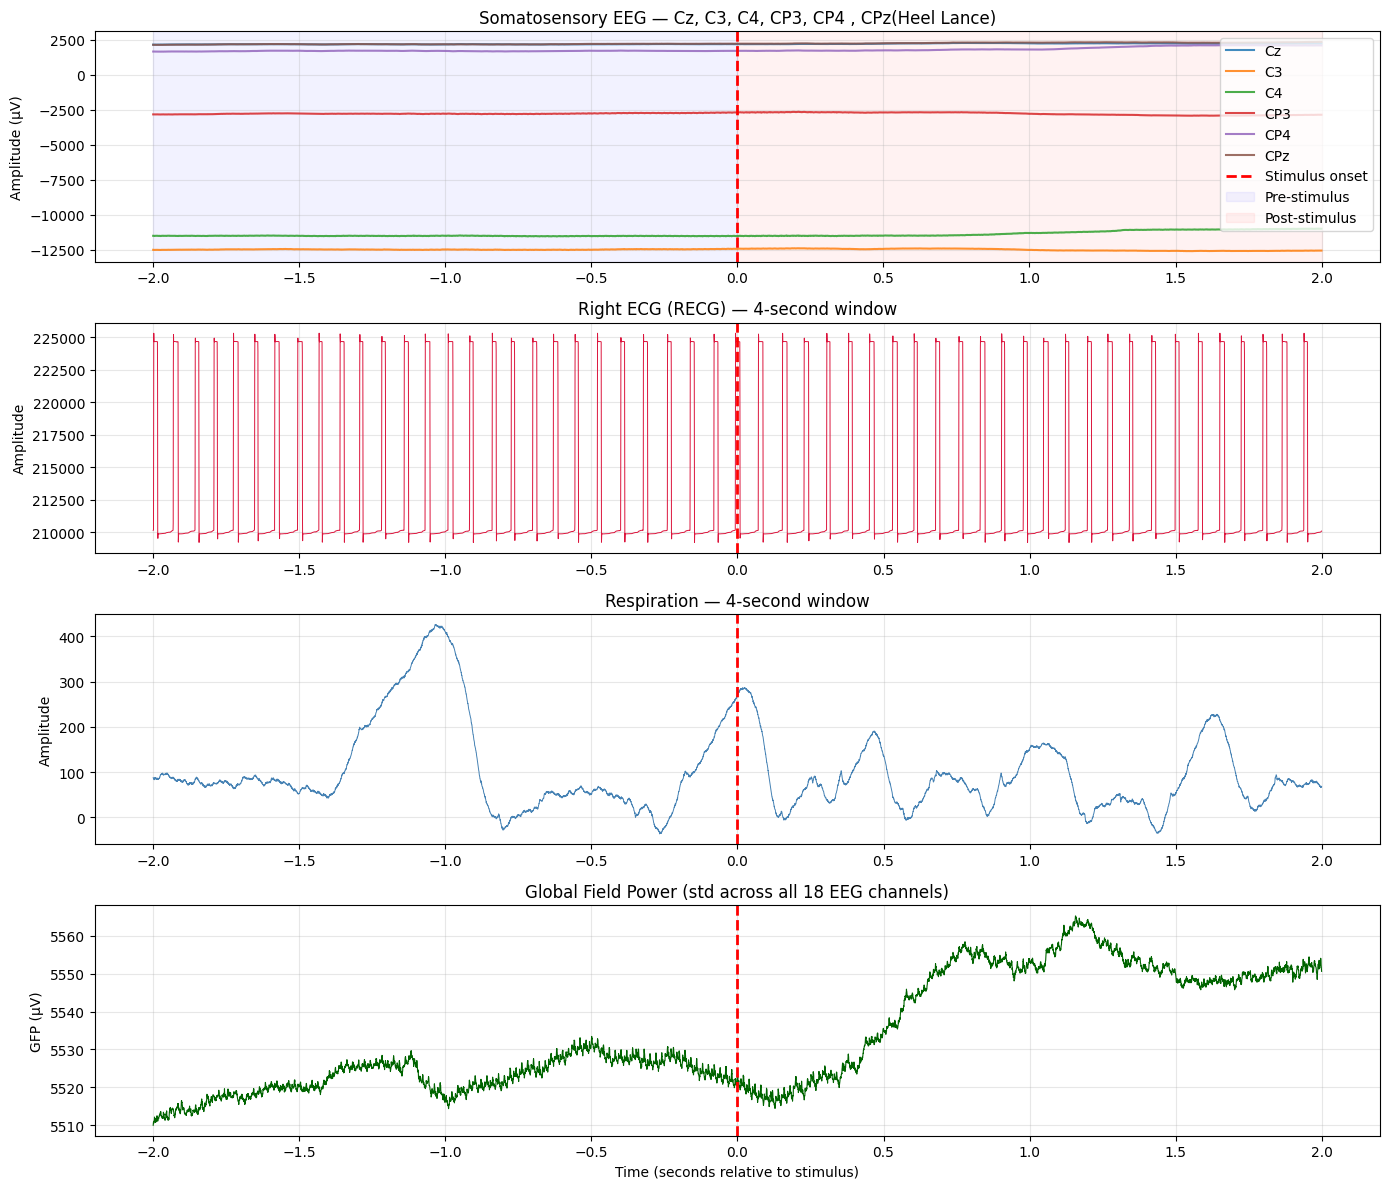

✅ Signal plot saved.
Time axis: -2.00s to 2.00s
EEG channels: ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz']
other_data labels: ['RECG', 'LECG', 'Resp']


In [5]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"

# Load one lance file
mat = scipy.io.loadmat(
    f"{ucl_eeg_path}\\2510001\\2510001L01.mat",
    squeeze_me=True, struct_as_record=False
)
eeg = mat['EEG']

# EEG data — confirmed (18, 8000)
eeg_data = eeg.data
times    = eeg.times / 1000   # ms → seconds, gives -2.0 to +1.9995
srate    = eeg.srate           # 2000 Hz

# ── Fix: access other_data correctly ──────────────────────────────────
# od.data with squeeze_me returns the raw MATLAB array — need direct attribute
od = eeg.other_data
# od._fieldnames confirmed as ['data', 'labels']
# od.data is the raw signal, but may be full-length — slice to 8000 points
raw_od = od.data
print(f"od.data raw shape : {raw_od.shape}")

# Slice to match EEG window: take first 3 rows, first 8000 columns
if raw_od.ndim == 2:
    if raw_od.shape[1] >= 8000:
        od_data = raw_od[:3, :8000]   # (3, 8000): RECG, LECG, Resp
    else:
        od_data = raw_od[:3, :]
elif raw_od.ndim == 1:
    od_data = raw_od.reshape(3, -1)[:, :8000]

print(f"od_data after fix : {od_data.shape}")  # must be (3, 8000)

recg_signal = od_data[0]   # Right ECG
resp_signal = od_data[2]   # Respiration

print(f"recg_signal shape : {recg_signal.shape}")   # must be (8000,)
print(f"resp_signal shape : {resp_signal.shape}")   # must be (8000,)
print(f"times shape       : {times.shape}")          # must be (8000,)

# Channel names
ch_names = [str(eeg.chanlocs[i].labels) for i in range(len(eeg.chanlocs))]

# Somatosensory channels most relevant for pain
soma_channels = ['Cz', 'C3', 'C4', 'CP3', 'CP4', 'CPz']
soma_idx = [ch_names.index(c) for c in soma_channels if c in ch_names]

# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: Somatosensory EEG
for ch_i in soma_idx:
    axes[0].plot(times, eeg_data[ch_i],
                 linewidth=1.5, label=ch_names[ch_i], alpha=0.85)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Stimulus onset')
axes[0].axvspan(-2, 0, alpha=0.05, color='blue', label='Pre-stimulus')
axes[0].axvspan(0,  2, alpha=0.05, color='red',  label='Post-stimulus')
axes[0].set_title('Somatosensory EEG — Cz, C3, C4, CP3, CP4 , CPz(Heel Lance)')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Right ECG
axes[1].plot(times, recg_signal, color='crimson', linewidth=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Right ECG (RECG) — 4-second window')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

# Plot 3: Respiration
axes[2].plot(times, resp_signal, color='steelblue', linewidth=0.7)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Respiration — 4-second window')
axes[2].set_ylabel('Amplitude')
axes[2].grid(True, alpha=0.3)

# Plot 4: Global Field Power
gfp = np.std(eeg_data, axis=0)
axes[3].plot(times, gfp, color='darkgreen', linewidth=0.8)
axes[3].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[3].set_title('Global Field Power (std across all 18 EEG channels)')
axes[3].set_ylabel('GFP (μV)')
axes[3].set_xlabel('Time (seconds relative to stimulus)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    r"C:\Users\Asus\OneDrive\Desktop\neopain-research\outputs\figures\ucl_single_file_signals.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Signal plot saved.")
print(f"Time axis: {times[0]:.2f}s to {times[-1]:.2f}s")
print(f"EEG channels: {[ch_names[i] for i in soma_idx]}")
print(f"other_data labels: {list(od.labels)}")

In [7]:
import scipy.io
import numpy as np
import pandas as pd
from scipy import signal as sp_signal
import neurokit2 as nk
import os
import re

ucl_eeg_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\raw\UCL\EEG"
save_path    = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"

# Load master label table
master = pd.read_csv(f"{save_path}\\ucl_master_labels.csv")

# ── Rebuild mat_path from EEG file name — don't trust CSV path column ──
def rebuild_path(eeg_fname):
    fname  = str(eeg_fname).strip()
    match  = re.match(r'^(\d+)[ACL]', fname)
    folder = match.group(1) if match else fname[:7]
    return f"{ucl_eeg_path}\\{folder}\\{fname}.mat"

master['mat_path']    = master['EEG file name'].apply(rebuild_path)
master['file_exists'] = master['mat_path'].apply(os.path.exists)
master = master[master['file_exists'] == True].reset_index(drop=True)
print(f"Files to process: {len(master)}")
print(f"Columns in master: {list(master.columns)}")

# ── Signal parameters ──────────────────────────────────────────────────
srate    = 2000
ch_names = ['Cz','CPz','F8','T8','TP10','P8','O2','F4','C4','CP4',
            'F7','T7','TP9','P7','O1','F3','C3','CP3']
soma_chs = ['Cz', 'CPz', 'C3', 'C4', 'CP3', 'CP4']
soma_idx = [ch_names.index(c) for c in soma_chs if c in ch_names]

def bandpower(signal_1d, fs, fmin, fmax):
    freqs, psd = sp_signal.welch(signal_1d, fs=fs,
                                  nperseg=min(256, len(signal_1d)))
    idx = np.logical_and(freqs >= fmin, freqs <= fmax)
    return float(np.trapz(psd[idx], freqs[idx]))

def extract_features(mat_path):
    try:
        mat = scipy.io.loadmat(mat_path, squeeze_me=True,
                                struct_as_record=False)
        eeg   = mat['EEG']
        data  = eeg.data     # (18, 8000)
        times = eeg.times    # ms: -2000 to +1999.5

        pre_idx      = times < 0
        post_idx     = (times >= 0) & (times <= 1000)
        post_500_idx = (times >= 0) & (times <= 500)

        features = {}

        # ── EEG features per somatosensory channel ────────────────────
        for ch_i in soma_idx:
            ch   = ch_names[ch_i]
            sig  = data[ch_i]
            pre  = sig[pre_idx]
            post = sig[post_idx]

            features[f'{ch}_delta_post']   = bandpower(post, srate, 1, 4)
            features[f'{ch}_theta_post']   = bandpower(post, srate, 4, 8)
            features[f'{ch}_alpha_post']   = bandpower(post, srate, 8, 13)

            pre_delta = bandpower(pre, srate, 1, 4)
            features[f'{ch}_delta_change'] = (
                features[f'{ch}_delta_post'] / (pre_delta + 1e-10)
            )
            features[f'{ch}_erp_peak'] = float(
                np.max(np.abs(sig[post_500_idx]))
            )
            features[f'{ch}_erp_mean'] = float(np.mean(sig[post_500_idx]))

        # ── Global Field Power ────────────────────────────────────────
        gfp_post = np.std(data[:, post_idx], axis=0)
        features['gfp_mean_post'] = float(np.mean(gfp_post))
        features['gfp_max_post']  = float(np.max(gfp_post))

        # ── ECG from other_data ───────────────────────────────────────
        od     = eeg.other_data
        raw_od = od.data
        # Slice to 8000 points matching EEG window
        if raw_od.ndim == 2 and raw_od.shape[1] >= 8000:
            od_data = raw_od[:3, :8000]
        elif raw_od.ndim == 2:
            od_data = raw_od[:3, :]
        else:
            od_data = raw_od.reshape(3, -1)[:, :8000]

        recg = od_data[0]   # Right ECG, shape (8000,)

        try:
            recg_clean = nk.ecg_clean(recg, sampling_rate=srate)
            _, info    = nk.ecg_peaks(recg_clean, sampling_rate=srate)
            rpeaks     = info['ECG_R_Peaks']

            stim_sample = np.where(times >= 0)[0][0]
            pre_peaks   = rpeaks[rpeaks < stim_sample]
            post_peaks  = rpeaks[rpeaks >= stim_sample]

            pre_hr  = len(pre_peaks)  / 2.0 * 60
            post_hr = len(post_peaks) / 2.0 * 60

            features['ecg_pre_hr']    = float(pre_hr)
            features['ecg_post_hr']   = float(post_hr)
            features['ecg_hr_change'] = float(post_hr - pre_hr)
        except Exception:
            features['ecg_pre_hr']    = np.nan
            features['ecg_post_hr']   = np.nan
            features['ecg_hr_change'] = np.nan

        # ── Respiration ───────────────────────────────────────────────
        resp = od_data[2]
        features['resp_mean_post'] = float(np.mean(resp[post_idx]))
        features['resp_std_post']  = float(np.std(resp[post_idx]))

        return features

    except Exception as ex:
        return None

# ── Main extraction loop ──────────────────────────────────────────────
all_rows = []
failed   = 0

for i, row in master.iterrows():
    feats = extract_features(row['mat_path'])
    if feats is None:
        failed += 1
        continue

    # Metadata from master table
    feats['mat_path']           = row['mat_path']
    feats['EEG file name']      = row['EEG file name']
    feats['Record identifier']  = row['Record identifier']
    feats['condition']          = row['condition']
    feats['pain_label']         = row['pain_label']
    feats['pipp_label']         = row['pipp_label'] if 'pipp_label' in row else np.nan
    feats['Total PIPP score']   = row['Total PIPP score'] if 'Total PIPP score' in row else np.nan
    feats['age_group']          = row['age_group'] if 'age_group' in row else 'unknown'
    feats['on_analgesic']       = row['on_analgesic'] if 'on_analgesic' in row else 0

    # PIPP physiological values
    feats['pipp_baseline_hr']   = row.get('Baseline heart rate (bmp)',  np.nan) if hasattr(row, 'get') else np.nan
    feats['pipp_max_hr']        = row.get('Max heart rate (bpm)',        np.nan) if hasattr(row, 'get') else np.nan
    feats['pipp_hr_change']     = (feats['pipp_max_hr'] - feats['pipp_baseline_hr'])
    feats['pipp_baseline_spo2'] = row.get('Baseline O2 sats',           np.nan) if hasattr(row, 'get') else np.nan
    feats['pipp_min_spo2']      = row.get('Min O2 sats',                np.nan) if hasattr(row, 'get') else np.nan
    feats['pipp_spo2_drop']     = (feats['pipp_baseline_spo2'] - feats['pipp_min_spo2'])

    all_rows.append(feats)

    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(master)} ...")

feature_df = pd.DataFrame(all_rows)
print(f"\n✅ Done. Rows: {len(feature_df)}, Columns: {len(feature_df.columns)}")
print(f"Failed: {failed}")
print(f"\nSample:")
sample_cols = ['EEG file name','condition','pain_label',
               'Cz_delta_post','Cz_erp_peak','ecg_hr_change']
print(feature_df[sample_cols].head(5).to_string())

feature_df.to_csv(f"{save_path}\\ucl_feature_matrix.csv", index=False)
print(f"\n✅ Saved ucl_feature_matrix.csv — {len(feature_df)} rows")

Files to process: 308
Columns in master: ['Record identifier', 'EEG file name', 'condition', 'pain_label', 'Total PIPP score', 'pipp_label', 'Gestational age at birth (weeks)', 'age_group', 'on_analgesic', 'Baseline heart rate (bmp)', 'Max heart rate (bpm)', 'Baseline O2 sats', 'Min O2 sats', 'file_exists', 'mat_path']


C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users

  Processed 50/308 ...


C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users

  Processed 100/308 ...


...

C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users

  Processed 300/308 ...


C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))



✅ Done. Rows: 286, Columns: 58
Failed: 22

Sample:
  EEG file name condition  pain_label  Cz_delta_post  Cz_erp_peak  ecg_hr_change
0     252101L01     lance           1            0.0   175.535675           30.0
1     252601L01     lance           1            0.0  8879.601562          -30.0
2     252801L01     lance           1            0.0  4612.743652           30.0
3     253101L01     lance           1            0.0  3733.635010           30.0
4     253201L01     lance           1            0.0  4274.308594          -30.0

✅ Saved ucl_feature_matrix.csv — 286 rows


C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))
C:\Users\Asus\AppData\Local\Temp\ipykernel_384\3041475809.py:39: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[idx], freqs[idx]))


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
df = pd.read_csv(f"{save_path}\\ucl_feature_matrix.csv")

print("=" * 50)
print("FEATURE MATRIX INSPECTION")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nCondition breakdown:")
print(df['condition'].value_counts().to_string())
print(f"\nPain label breakdown:")
print(df['pain_label'].value_counts().to_string())

# NaN analysis
feat_cols = [c for c in df.columns
             if c not in ['mat_path','EEG file name','Record identifier',
                           'condition','pain_label','pipp_label',
                           'Total PIPP score','age_group','on_analgesic']]
nan_pct = df[feat_cols].isna().mean() * 100
high_nan = nan_pct[nan_pct > 30]
print(f"\nFeature columns with >30% NaN (will be dropped): {len(high_nan)}")
print(high_nan.sort_values(ascending=False).head(10).to_string())

# Drop high-NaN columns
df_clean = df.drop(columns=high_nan.index.tolist())
feat_cols_clean = [c for c in feat_cols if c not in high_nan.index]
print(f"\nFeatures after dropping high-NaN: {len(feat_cols_clean)}")

# Fill remaining NaNs with column median
df_clean[feat_cols_clean] = df_clean[feat_cols_clean].fillna(
    df_clean[feat_cols_clean].median()
)
print(f"Remaining NaNs after fill: {df_clean[feat_cols_clean].isna().sum().sum()}")

# Class balance
pain_count   = (df_clean['pain_label'] == 1).sum()
nopain_count = (df_clean['pain_label'] == 0).sum()
print(f"\nClass balance:")
print(f"  Pain (1)    : {pain_count} ({pain_count/len(df_clean)*100:.1f}%)")
print(f"  No pain (0) : {nopain_count} ({nopain_count/len(df_clean)*100:.1f}%)")

# Save clean version
df_clean.to_csv(f"{save_path}\\ucl_feature_matrix_clean.csv", index=False)
print(f"\n✅ Saved ucl_feature_matrix_clean.csv — {len(df_clean)} rows, "
      f"{len(feat_cols_clean)} features")

FEATURE MATRIX INSPECTION
Shape: (286, 58)

Condition breakdown:
condition
lance       100
sham         93
auditory     93

Pain label breakdown:
pain_label
0    186
1    100

Feature columns with >30% NaN (will be dropped): 0
Series([], )

Features after dropping high-NaN: 49
Remaining NaNs after fill: 0

Class balance:
  Pain (1)    : 100 (35.0%)
  No pain (0) : 186 (65.0%)

✅ Saved ucl_feature_matrix_clean.csv — 286 rows, 49 features


In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

save_path = r"C:\Users\Asus\OneDrive\Desktop\neopain-research\data\processed"
df = pd.read_csv(f"{save_path}\\ucl_feature_matrix_clean.csv")

# Feature columns only — exclude metadata and label columns
meta_cols = ['mat_path','EEG file name','Record identifier','condition',
             'pain_label','pipp_label','Total PIPP score',
             'age_group','on_analgesic']
feat_cols = [c for c in df.columns if c not in meta_cols]

X = df[feat_cols].values
y = df['pain_label'].values
subjects = df['Record identifier'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Unique subjects: {len(np.unique(subjects))}")

# LOSO cross-validation
# For each subject: train on all others, test on this one
all_auc, all_f1 = [], []
unique_subj = np.unique(subjects)

for subj in unique_subj:
    test_mask  = subjects == subj
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # Skip if only one class in test set
    if len(np.unique(y_test)) < 2:
        continue

    # Scale features
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # XGBoost — scale_pos_weight handles class imbalance
    scale_pw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pw,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    try:
        auc = roc_auc_score(y_test, y_prob)
        f1  = f1_score(y_test, y_pred, zero_division=0)
        all_auc.append(auc)
        all_f1.append(f1)
    except Exception:
        continue

print("=" * 50)
print("LOSO CROSS-VALIDATION RESULTS")
print("=" * 50)
print(f"Subjects evaluated : {len(all_auc)}")
print(f"Mean AUC           : {np.mean(all_auc):.3f} ± {np.std(all_auc):.3f}")
print(f"Mean F1            : {np.mean(all_f1):.3f} ± {np.std(all_f1):.3f}")
print(f"\nBaselines to beat:")
print(f"  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%")
print(f"  Roué  2025 (GB, full set)    : AUC 0.90")

Feature matrix shape: (286, 49)
Unique subjects: 102
LOSO CROSS-VALIDATION RESULTS
Subjects evaluated : 92
Mean AUC           : 0.712 ± 0.385
Mean F1            : 0.420 ± 0.422

Baselines to beat:
  Hamwi 2025 (LR, oldest group): AUC 0.94, Acc 82%
  Roué  2025 (GB, full set)    : AUC 0.90
